## Import Libraries

In [7]:
import cv2
import os
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
%matplotlib inline  
from pathlib import Path
import pandas as pd 

## List Classes

In [21]:
IMG_SIZE    = (128, 128)
DATASET_DIR = Path('Faces')

In [23]:
names  = sorted([p.name for p in DATASET_DIR.iterdir() if p.is_dir()])
labels = list(range(1, len(names) + 1))

name_to_label = dict(zip(names, labels))
label_to_name = {v: k for k, v in name_to_label.items()}

print(f"Classes ({len(names)}): {names}")

Classes (25): ['Akshay Kumar', 'Alexandra Daddario', 'Amitabh Bachchan', 'Andy Samberg', 'Billie Eilish', 'Brad Pitt', 'Camila Cabello', 'Charlize Theron', 'Claire Holt', 'Courtney Cox', 'Dwayne Johnson', 'Elizabeth Olsen', 'Ellen Degeneres', 'Henry Cavill', 'Hrithik Roshan', 'Lisa Kudrow', 'Margot Robbie', 'Natalie Portman', 'Priyanka Chopra', 'Robert Downey Jr', 'Roger Federer', 'Tom Cruise', 'Vijay Deverakonda', 'Virat Kohli', 'Zac Efron']


## Load Data & Resizing & Shuffling

In [35]:
records = []

for name, label in name_to_label.items():
    for img_path in (DATASET_DIR / name).iterdir():
        if not img_path.is_file():
            continue

        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"Warning: could not read {img_path}, skipping.")
            continue

        img = cv2.resize(img, IMG_SIZE).flatten()
        records.append(np.append(img, label))

dataset = np.array(records)

np.random.seed(10)
np.random.shuffle(dataset)

print(f"Dataset shape: {dataset.shape}")

Dataset shape: (1225, 16385)


In [25]:
images = dataset[:, :-1].reshape(-1, *IMG_SIZE)
Y      = dataset[:, -1]

## Sample Visualization

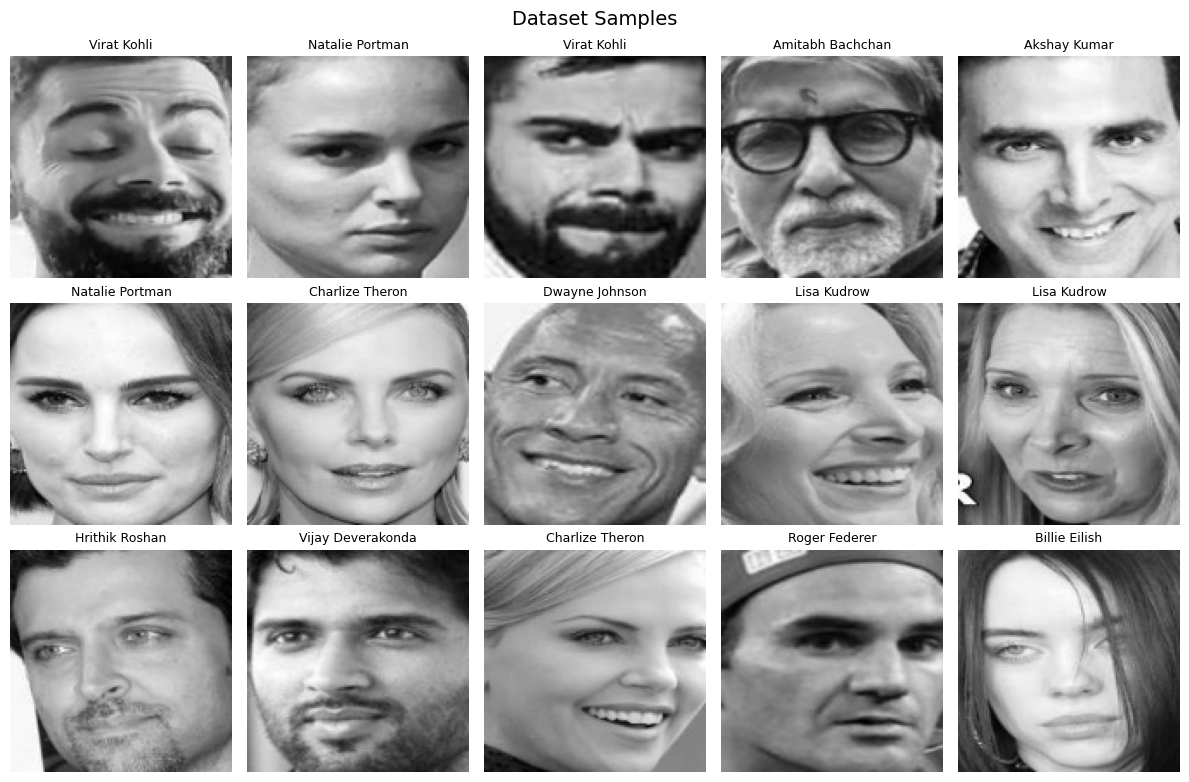

In [36]:
fig, axes = plt.subplots(3, 5, figsize=(12, 8))

for ax, image, label in zip(axes.ravel(), images, Y):
    ax.imshow(image, cmap='gray')
    ax.set_title(label_to_name[label], fontsize=9)
    ax.axis('off')

plt.suptitle('Dataset Samples', fontsize=14)
plt.tight_layout()
plt.show()

## Gaussian Filter

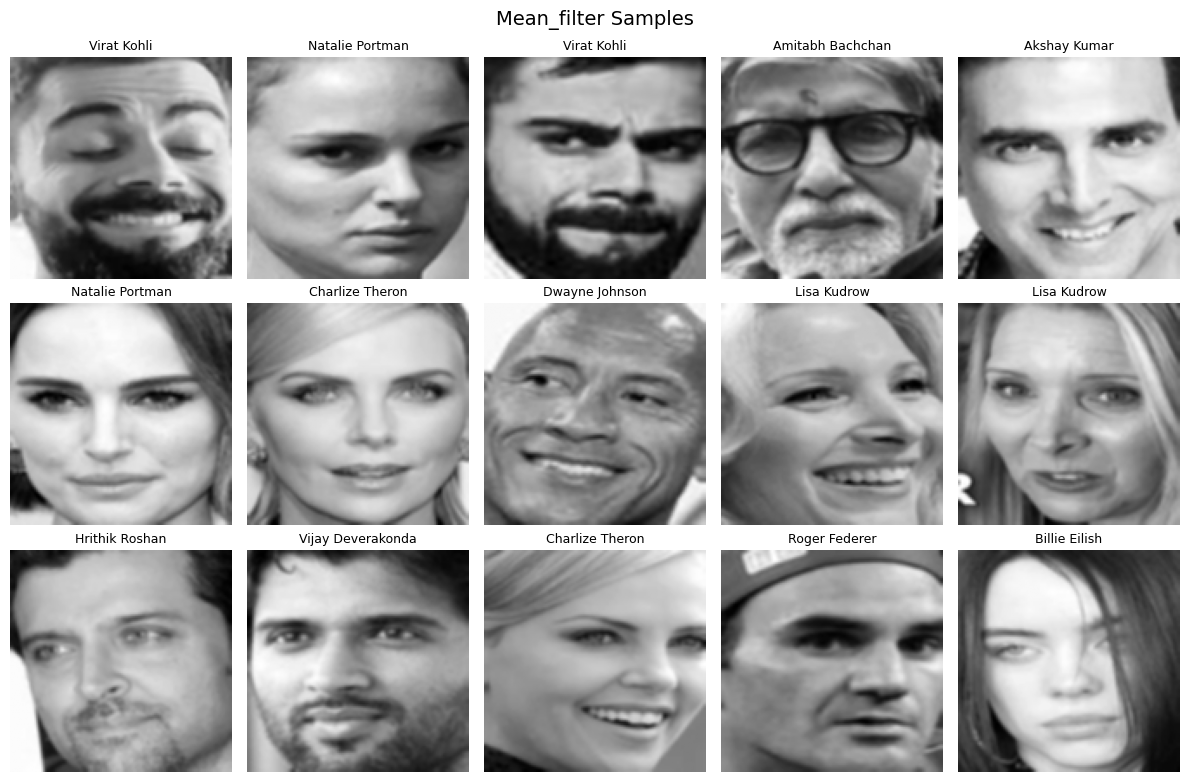

In [37]:

meanf_images = []

for image in images:
    img_2d = image.reshape(IMG_SIZE).astype(np.uint8)
    Gaussian = cv2.GaussianBlur(img_2d, (3,3), sigmaX=1.0)
    meanf_images.append(Gaussian)

meanf_images = np.array(meanf_images)

fig, axes = plt.subplots(3, 5, figsize=(12, 8))
for ax, image, label in zip(axes.ravel(), meanf_images, Y):
    ax.imshow(image, cmap='gray')
    ax.set_title(label_to_name[label], fontsize=9)
    ax.axis('off')

plt.suptitle('Mean_filter Samples', fontsize=14)
plt.tight_layout()
plt.show()

In [38]:
psnr_values = []

for img1, img2 in zip(images, meanf_images):
    img1 = img1.astype(np.float32)
    img2 = img2.astype(np.float32)
    
    psnr = cv2.PSNR(img1, img2)
    psnr_values.append(psnr)

mean_psnr = np.mean(psnr_values)

print("Mean PSNR:", mean_psnr)

Mean PSNR: 34.11433568714832


## Salt-and-Paper Filter

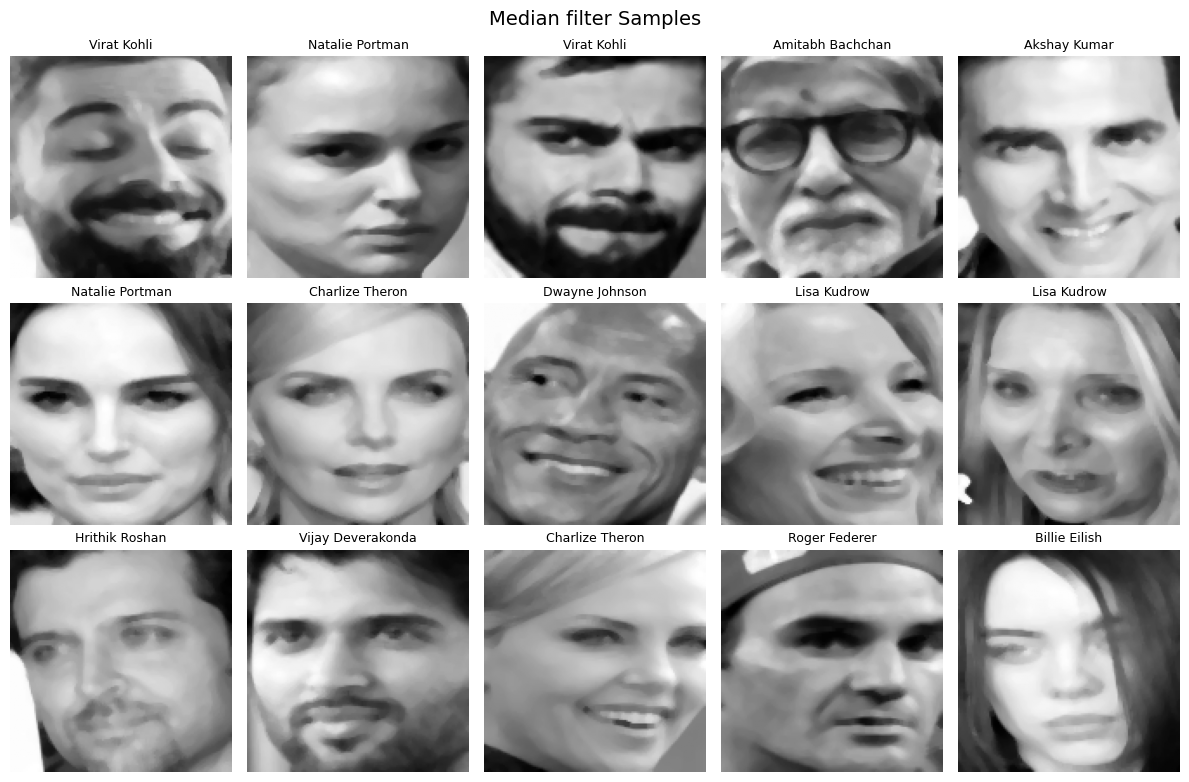

In [39]:
medianf_images = []

for image in images:
    median  = cv2.medianBlur(image.astype(np.uint8), 5 )
    medianf_images.append(median )

medianf_images = np.array(medianf_images)


fig, axes = plt.subplots(3, 5, figsize=(12, 8))

for ax, image, label in zip(axes.ravel(), medianf_images, Y):
    ax.imshow(image, cmap='gray')
    ax.set_title(label_to_name[label], fontsize=9)
    ax.axis('off')

plt.suptitle('Median filter Samples', fontsize=14)

plt.tight_layout()
plt.show()

In [40]:
psnr_values = []

for img1, img2 in zip(images, medianf_images):
    img1 = img1.astype(np.float32)
    img2 = img2.astype(np.float32)
    
    psnr = cv2.PSNR(img1, img2)
    psnr_values.append(psnr)

mean_psnr = np.mean(psnr_values)

print("Mean PSNR:", mean_psnr)

Mean PSNR: 30.36993132353916


## Harris Corner Implementation

In [41]:
harris_images = {0.01: [], 0.05: [], 0.1: []}


for img in meanf_images:

    img_float = np.float32(img)

    harris = cv2.cornerHarris(img_float, blockSize=3, ksize=3, k=0.04)


    harris = cv2.dilate(harris, None)

    for thresh in [0.01, 0.05, 0.1]:

        corners = img.copy()

        corners[harris > thresh * harris.max()] = 255

        harris_images[thresh].append(corners)

for k in harris_images:
    harris_images[k] = np.array(harris_images[k])

## Harris Corner Visualization

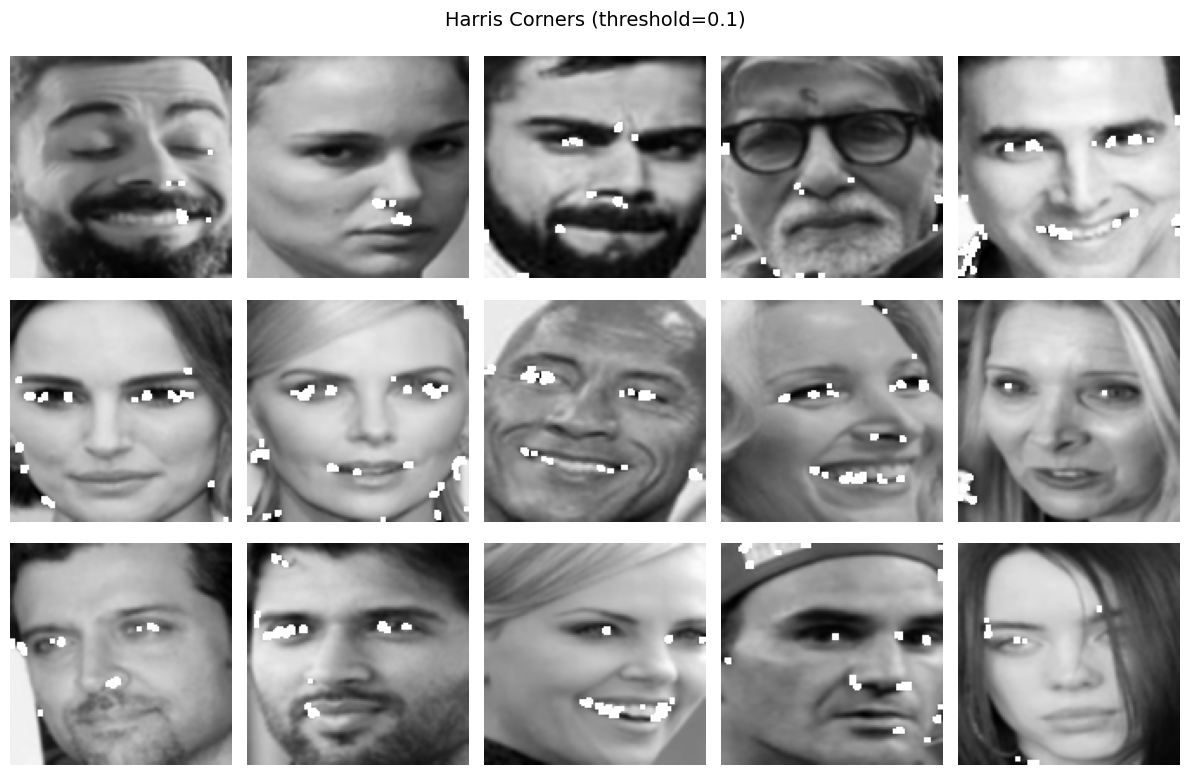

In [42]:
fig, axes = plt.subplots(3, 5, figsize=(12, 8))

threshold = 0.1

for ax, img in zip(axes.ravel(), harris_images[threshold]):
    ax.imshow(img, cmap='gray')
    ax.axis('off')

plt.suptitle(f'Harris Corners (threshold={threshold})', fontsize=14)
plt.tight_layout()
plt.show()

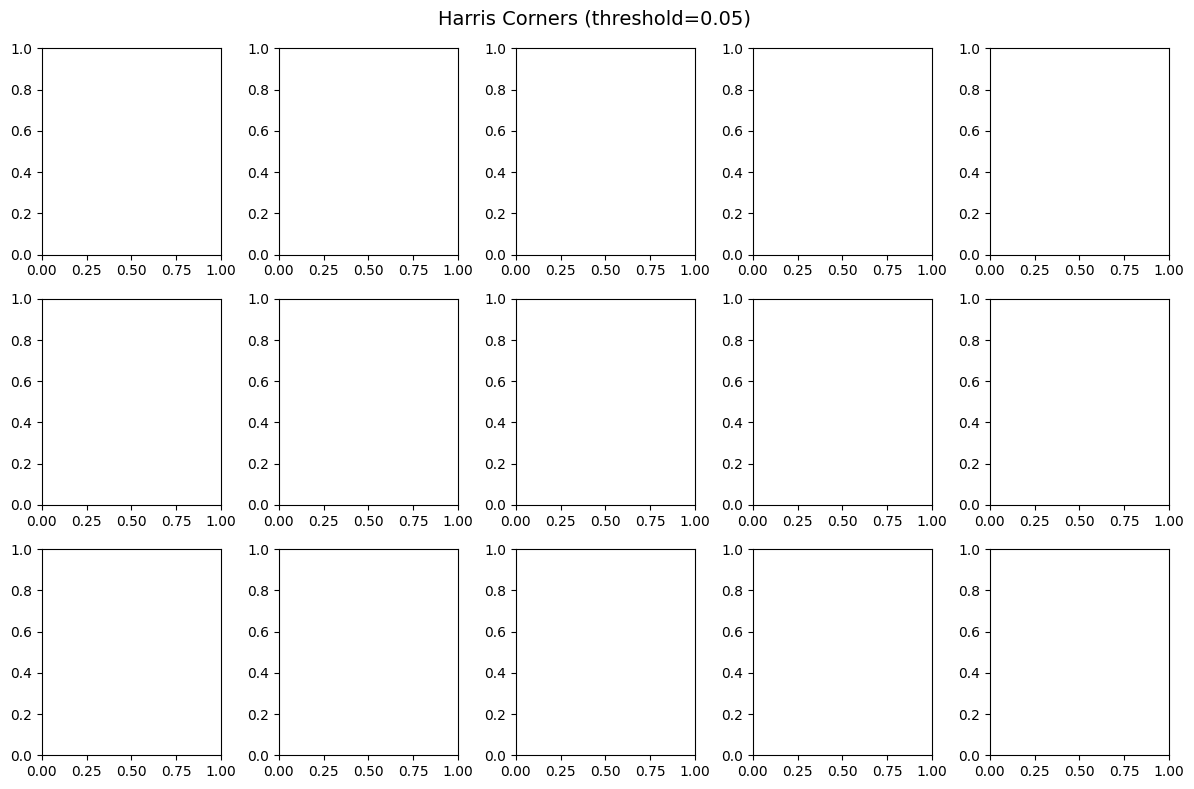

In [19]:
fig, axes = plt.subplots(3, 5, figsize=(12, 8))

threshold = 0.05

for ax, img in zip(axes.ravel(), harris_images[threshold]):
    ax.imshow(img, cmap='gray')
    ax.axis('off')

plt.suptitle(f'Harris Corners (threshold={threshold})', fontsize=14)
plt.tight_layout()
plt.show()


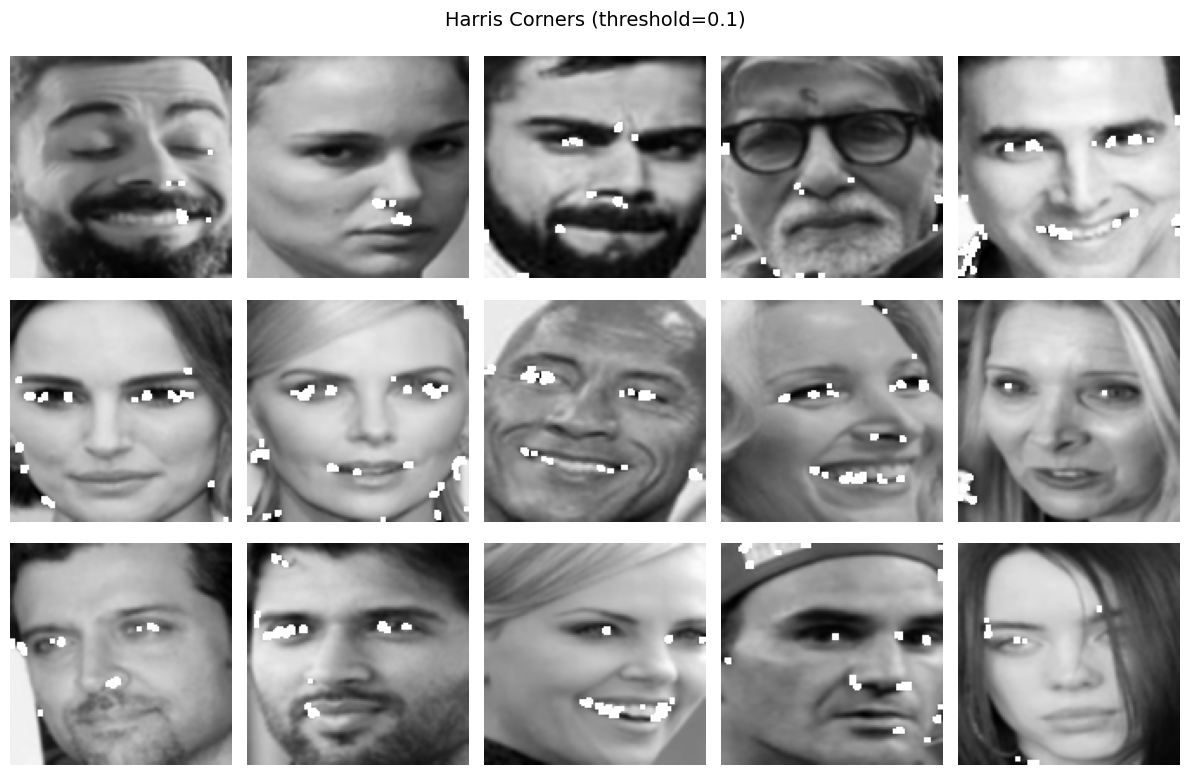

In [43]:
fig, axes = plt.subplots(3, 5, figsize=(12, 8))

threshold = 0.1

for ax, img in zip(axes.ravel(), harris_images[threshold]):
    ax.imshow(img, cmap='gray')
    ax.axis('off')

plt.suptitle(f'Harris Corners (threshold={threshold})', fontsize=14)
plt.tight_layout()
plt.show()

## Haar Cascade 

In [44]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

haar_results = {0.01: [], 0.05: [], 0.1: []}

for thresh, images in harris_images.items():
    for img in images:
        # Harris output بيبقى grayscale، Haar محتاج BGR
        img_bgr = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

        result = img_bgr.copy()
        for (x, y, w, h) in faces:
            cv2.rectangle(result, (x, y), (x+w, y+h), (0, 255, 0), 2)

        haar_results[thresh].append(result)

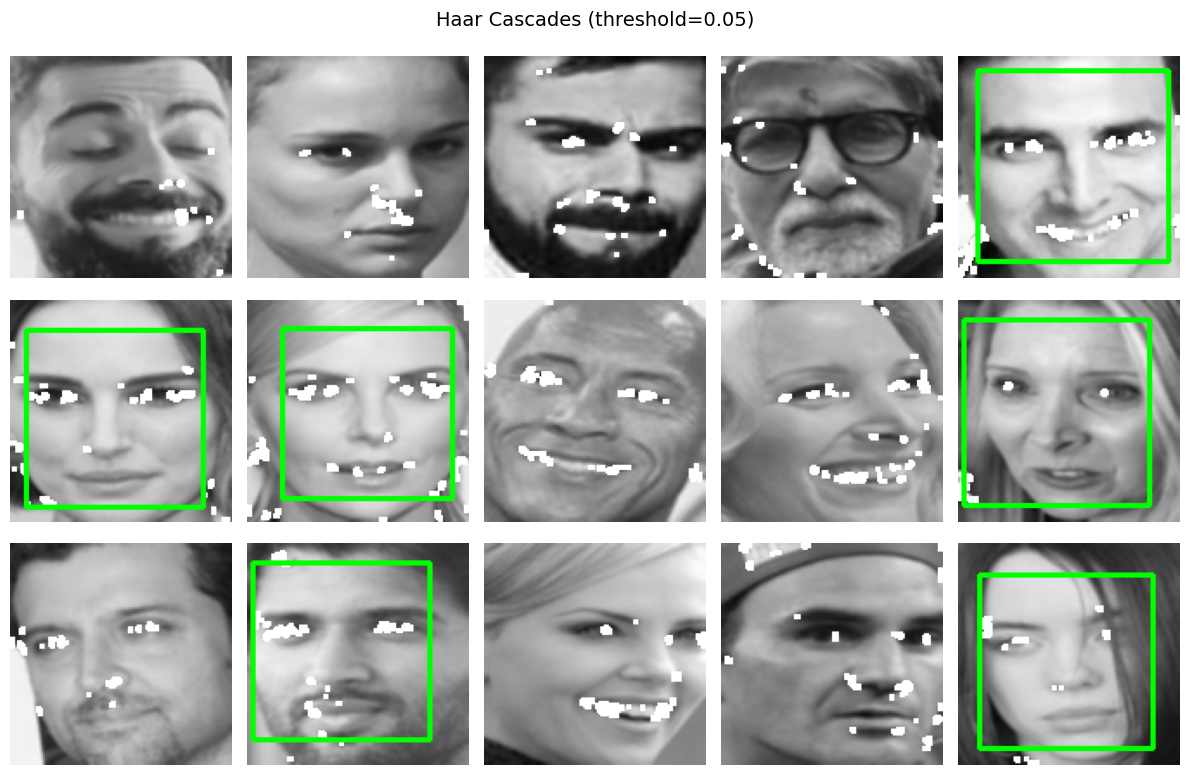

In [52]:
fig, axes = plt.subplots(3, 5, figsize=(12, 8))

threshold = 0.05

for ax, img in zip(axes.ravel(), haar_results[threshold]):
    ax.imshow(img, cmap='gray')
    ax.axis('off')

plt.suptitle(f'Haar Cascades (threshold={threshold})', fontsize=14)
plt.tight_layout()
plt.show()
